# 🔍 Singapore Talent Market Intelligence
## NumPy / Pandas / EDA Hackathon — Persona A: The Career Coach

**Dataset:** SGJobData.csv (~1.05M Singapore job postings, Oct 2022 – May 2024)  
**Tooling:** Python — NumPy, Pandas, Matplotlib, Seaborn  
**Team Persona:** Career Coach — *"Which industry should mid-career professionals switch into?"*

---

### Notebook Structure
| Section | Description |
|---------|-------------|
| **Part 1: EDA** | Understand the raw dataset — structure, quality, distributions |
| **Part 2: Data Cleaning** | Handle outliers, nulls, duplicates, and parse categories |
| **Part 3: Persona A Analysis** | 6 analytical questions with charts and findings |
| **Part 4: Summary** | Key insights, caveats, and recommendation |

---

---
## Part 1: Exploratory Data Analysis (EDA)

> **Goal:** Before writing any business logic, we systematically profile the dataset to understand its structure, quality, and distributions. This informs every cleaning decision we make later.

---

### Step 1 · Imports & Load

In [6]:
# ── Step 1: Imports and Load ──
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Load CSV — takes ~10-15 seconds
df = pd.read_csv('SGJobData.csv', low_memory=False)
print(df.shape)  # (1048585, 22)
print(df.dtypes)
print(df.head(3))

(1048585, 22)
categories                             object
employmentTypes                        object
metadata_expiryDate                    object
metadata_isPostedOnBehalf                bool
metadata_jobPostId                     object
metadata_newPostingDate                object
metadata_originalPostingDate           object
metadata_repostCount                    int64
metadata_totalNumberJobApplication      int64
metadata_totalNumberOfView              int64
minimumYearsExperience                  int64
numberOfVacancies                       int64
occupationId                          float64
positionLevels                         object
postedCompany_name                     object
salary_maximum                          int64
salary_minimum                          int64
salary_type                            object
status_id                               int64
status_jobStatus                       object
title                                  object
average_salary      

### Step 2 · Basic Structure

We parse date columns immediately so all downstream date arithmetic works correctly.

In [7]:
# ── Step 2: Understand the basic structure of the dataset ──

# Date range of the dataset
df['metadata_originalPostingDate'] = pd.to_datetime(df['metadata_originalPostingDate'])
df['metadata_newPostingDate']       = pd.to_datetime(df['metadata_newPostingDate'])
df['metadata_expiryDate']           = pd.to_datetime(df['metadata_expiryDate'])

print(f'Date range: {df["metadata_originalPostingDate"].min()} to {df["metadata_originalPostingDate"].max()}')

Date range: 2022-10-03 00:00:00 to 2024-05-29 00:00:00


### Step 3 · Data Quality Assessment

We check for nulls, duplicates, and immediately drop columns/rows that are confirmed unusable.

In [8]:
# ── Step 3: Assess data quality ──

# 3a: Null counts per column
print('── Null counts ──')
print(df.isnull().sum().sort_values(ascending=False))

# 3b: Duplicate rows
print(f'\n── Duplicate rows: {df.duplicated().sum()} ──')

── Null counts ──
occupationId                          1048585
categories                               3988
metadata_expiryDate                      3988
title                                    3988
metadata_jobPostId                       3988
metadata_newPostingDate                  3988
metadata_originalPostingDate             3988
status_jobStatus                         3988
salary_type                              3988
employmentTypes                          3988
positionLevels                           3988
postedCompany_name                       3988
salary_maximum                              0
status_id                                   0
salary_minimum                              0
numberOfVacancies                           0
minimumYearsExperience                      0
metadata_totalNumberOfView                  0
metadata_totalNumberJobApplication          0
metadata_repostCount                        0
metadata_isPostedOnBehalf                   0
average_salary  

In [9]:
# 3c: Drop confirmed unusable data
# occupationId: 100% null, no analytical value
# salary_type: only one unique value 'Monthly', no analytical value
# 3,988 empty rows with null metadata_jobPostId: not real job postings
df = df.drop(columns=['occupationId', 'salary_type'])
df = df.dropna(subset=['metadata_jobPostId'])
print(f'\nShape after dropping: {df.shape}')  # Expect (1044597, 20)


Shape after dropping: (1044597, 20)


**📋 Data Quality Findings:**

| Issue | Detail | Action |
|-------|--------|--------|
| `occupationId` | 100% null — entire column has no data | Dropped immediately |
| `salary_type` | Only one value: `Monthly` — no analytical value | Dropped immediately |
| 3,988 empty rows | Null `metadata_jobPostId` — not real job postings | Dropped immediately |
| 3,987 duplicate rows | All from the 3,988 empty rows — no real duplicates in actual postings | Resolved by dropping empty rows |

### Step 4 · Numerical Distributions

We plot box plots for all numerical columns to visually identify outliers and impossible values.  
Two versions: **raw** (shows how extreme outliers are) and **outliers hidden** (shows the true distribution).

       average_salary  salary_minimum  salary_maximum  minimumYearsExperience  \
count    1.044597e+06    1.044597e+06    1.044597e+06            1.044597e+06   
mean     4.787654e+03    3.829878e+03    5.745429e+03            2.790185e+00   
std      2.552497e+04    3.169443e+03    5.027833e+04            2.536057e+00   
min      1.000000e+00    1.000000e+00    1.000000e+00            0.000000e+00   
25%      2.900000e+03    2.500000e+03    3.300000e+03            1.000000e+00   
50%      3.800000e+03    3.000000e+03    4.500000e+03            2.000000e+00   
75%      5.500000e+03    4.500000e+03    6.500000e+03            4.000000e+00   
max      1.266640e+07    3.500000e+05    2.533000e+07            8.800000e+01   

       numberOfVacancies  metadata_repostCount  \
count       1.044597e+06          1.044597e+06   
mean        2.690275e+00          5.493219e-02   
std         1.126322e+01          2.827855e-01   
min         1.000000e+00          0.000000e+00   
25%         1.000000

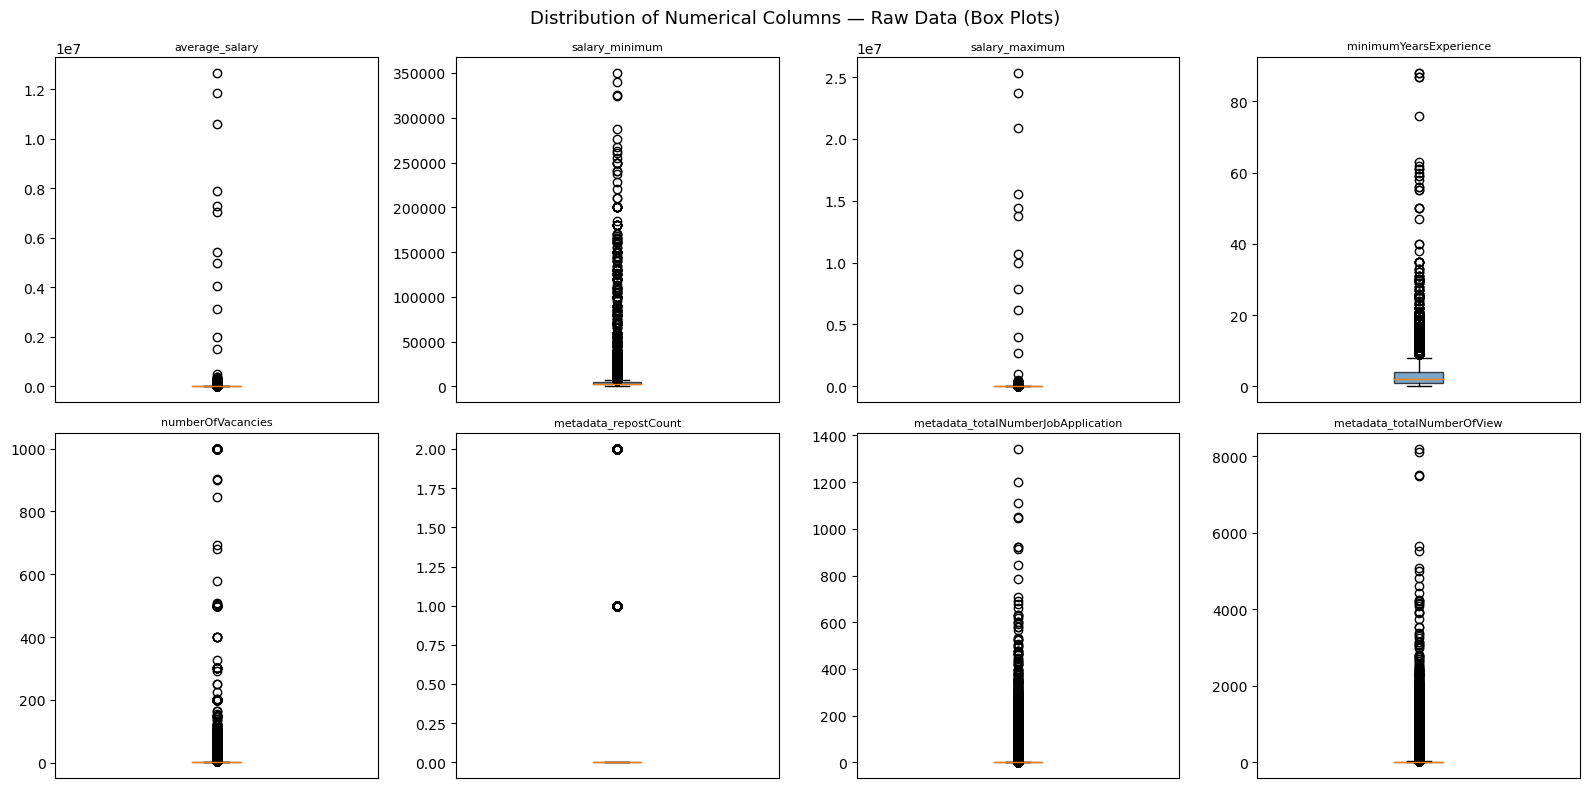

In [11]:
# ── Step 4: Statistical summary of numerical columns ──

num_cols = ['average_salary', 'salary_minimum', 'salary_maximum',
            'minimumYearsExperience', 'numberOfVacancies',
            'metadata_repostCount', 'metadata_totalNumberJobApplication',
            'metadata_totalNumberOfView']

print(df[num_cols].describe())

# Box plots to visualise distributions and identify outliers
# Raw box plots — shows how extreme the outliers are
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])
plt.suptitle('Distribution of Numerical Columns — Raw Data (Box Plots)', fontsize=13)
plt.tight_layout()
plt.show()


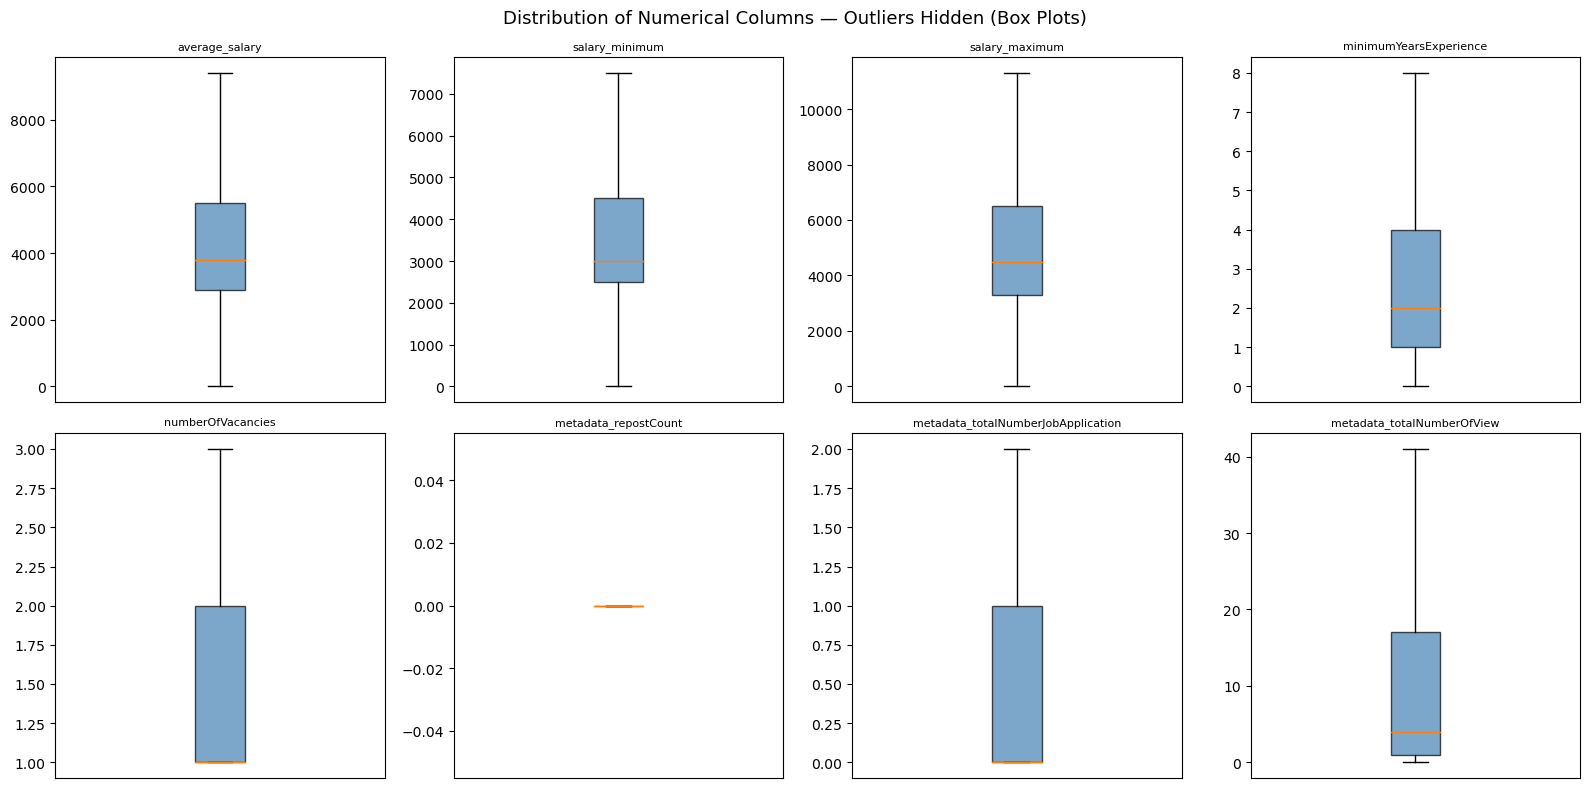

In [12]:
# Without outliers — shows the true distribution
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7),
                    showfliers=False)
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xticks([])
plt.suptitle('Distribution of Numerical Columns — Outliers Hidden (Box Plots)', fontsize=13)
plt.tight_layout()
plt.show()



**📋 Numerical Distribution Findings:**

- **Salary columns:** Raw plots reveal extreme outliers (up to $12M/month). True salary bulk sits between $2,500–$9,000 → cleaning threshold needed
- **minimumYearsExperience:** Values up to 88 years — clearly data entry errors → cap at 20 years
- **numberOfVacancies:** Mostly 1–2 per posting, a few extreme outliers
- **metadata_repostCount:** Median and IQR near 0 — most jobs are never reposted
- **metadata_totalNumberJobApplication / View:** Heavy right-skew — most jobs get few applications/views, a small number attract a lot

### Step 5 · Categorical Distributions

We inspect the key categorical columns for unexpected values, dominant groups, and hidden `None` strings.

In [13]:
# ── Step 5: Distribution of categorical columns ──
cat_cols = ['employmentTypes', 'positionLevels', 'status_jobStatus']

for col in cat_cols:
    print(f'\n── {col} ──')
    print(f'Unique values: {df[col].nunique()}')
    print(df[col].value_counts(dropna=False).head(10))


── employmentTypes ──
Unique values: 8
Permanent                458139
Full Time                393352
Contract                 139182
Part Time                 25431
Temporary                 18241
Internship/Attachment      6959
Freelance                  2139
Flexi-work                 1154
Name: employmentTypes, dtype: int64

── positionLevels ──
Unique values: 9
Executive            253701
Junior Executive     167656
Non-executive        131608
Fresh/entry level    118661
Professional         112208
Manager              110122
Senior Executive     100459
Middle Management     27375
Senior Management     22807
Name: positionLevels, dtype: int64

── status_jobStatus ──
Unique values: 3
Open       902614
Closed     119701
Re-open     22282
Name: status_jobStatus, dtype: int64


**📋 Categorical Distribution Findings:**

- **employmentTypes:** 8 values, clean. Permanent (44%) + Full Time (38%) = 82% of all postings
- **positionLevels:** 9 values, clean. Executive level dominates (24%), followed by Junior Executive (16%)
- **status_jobStatus:** 3 values — Open (86%), Closed (11%), Re-open (2%). No dirty values found
- **salary_type:** Constant value `Monthly` — already dropped in Step 3

---
## Part 2: Data Cleaning

> **Goal:** Apply systematic cleaning rules based on EDA findings. Every decision is documented and justified.

### Cleaning Plan
1. Filter salary outliers
2. Filter experience outliers  
3. Parse `categories` JSON string
4. Deduplicate using composite key + repostCount verification
5. Create derived columns

---

### Cleaning Step 1 · Salary Filter

**Rules (following instructor's cheat sheet):**
- Lower bound: `average_salary > 500`
- Upper bound: 99th percentile using `np.percentile` — data-driven, not arbitrary
- Additional: `salary_minimum > 100` to remove placeholder values (instructor note 5)

In [14]:
# ── Data Cleaning ──

# Step 1: Filter salary outliers (instructor cheat sheet)
# Lower bound: average_salary > 500
# Upper bound: 99th percentile (data-driven, not arbitrary)
# Additional: salary_minimum > 100 to remove placeholder values
p99 = np.percentile(df['average_salary'].dropna(), 99)
print(f'99th percentile of average_salary: ${p99:,.0f}')

before = len(df)
df_clean = df[
    (df['average_salary'] > 500) &
    (df['average_salary'] <= p99) &
    (df['salary_minimum'] > 100)
].copy()
print(f'Rows after salary filter: {len(df_clean):,}')
print(f'Removed: {before - len(df_clean):,} rows ({(before - len(df_clean))/before*100:.1f}%)')

99th percentile of average_salary: $16,750
Rows after salary filter: 1,025,660
Removed: 18,937 rows (1.8%)


### Cleaning Step 2 · Experience Filter

Values above 20 years (e.g. 88 years found in EDA) are clearly data entry errors.

In [15]:
# Step 2: Filter experience outliers
# Values > 20 years treated as data entry errors (88 years found in EDA)
before = len(df_clean)
df_clean = df_clean[df_clean['minimumYearsExperience'] <= 20].copy()
print(f'Rows after experience filter: {len(df_clean):,}')
print(f'Removed: {before - len(df_clean):,} rows')

Rows after experience filter: 1,025,441
Removed: 219 rows


### Cleaning Step 3 · Parse Categories

The `categories` column is a JSON string — a job can belong to multiple categories. We use regex to extract all category labels and create two versions:

- **`primary_category`**: first category only — fast, used for simple groupby
- **`df_exploded`**: one row per category per job — accurate for category-level counts

In [16]:
# Step 3: Parse categories
# categories column is a JSON string — use regex to extract category labels

def extract_all_categories(cat_str):
    if pd.isna(cat_str):
        return []
    return re.findall(r'"category"\s*:\s*"([^"]+)"', str(cat_str))

def extract_first_category(cat_str):
    cats = extract_all_categories(cat_str)
    return cats[0] if cats else np.nan

# Add primary_category to df_clean (first category only)
df_clean['primary_category'] = df_clean['categories'].apply(extract_first_category)

# Create exploded version (one row per category per job)
# Used for accurate category-level analysis
df_exploded = df_clean.copy()
df_exploded['all_categories'] = df_exploded['categories'].apply(extract_all_categories)
df_exploded = df_exploded.explode('all_categories').rename(
    columns={'all_categories': 'category'})
df_exploded = df_exploded.dropna(subset=['category'])

print(f'df_clean rows:    {len(df_clean):,}')
print(f'df_exploded rows: {len(df_exploded):,}')
print(f'Unique categories: {df_exploded["category"].nunique()}')

df_clean rows:    1,025,441
df_exploded rows: 1,737,702
Unique categories: 43


### Cleaning Step 4 · Deduplication Strategy

#### The Problem
The dataset contains re-posted jobs. When a job is re-posted, the platform assigns it a brand new `metadata_jobPostId`, so the instructor's suggested method of `drop_duplicates(subset='metadata_jobPostId')` cannot catch these duplicates — every re-post looks like a unique job.

#### Our Approach: Two-Layer Verification

**Layer 1 — Composite Key**  
We define a job's identity as the combination of three fields:
- `postedCompany_name` — who posted it
- `title` (lowercased and stripped) — what the job is
- `metadata_originalPostingDate` — when it was originally posted

**Layer 2 — repostCount Verification**  
Within each group sharing the same composite key, we check whether `metadata_repostCount` values are all distinct (e.g. 0, 1, 2):
- **All distinct (incrementing)** → confirmed re-post sequence → keep only the row with the lowest `repostCount`
- **Not all distinct (same value)** → likely genuine separate vacancies → keep all rows

#### Why Two Layers?
Using composite key alone risks over-deduplication. A restaurant genuinely hiring three cooks on the same day would have three identical-looking rows. The `repostCount` check catches this: if all three rows have `repostCount = 0`, they are not a re-post sequence — we keep all three.

> **Result:** Removed only **123 rows (0.01%)**, far fewer than composite key alone (~48,000 rows). This confirms we are removing only confirmed re-posts, not genuine multi-vacancy postings.

In [17]:
# Step 4: Deduplicate using composite key + repostCount verification
df_clean['dedup_key'] = (
    df_clean['postedCompany_name'].fillna('') + '|' +
    df_clean['title'].str.lower().str.strip().fillna('') + '|' +
    df_clean['metadata_originalPostingDate'].astype(str)
)

# Within each composite key group, find groups where repostCount values are all distinct
# (i.e. nunique == count) = confirmed repost sequence
group_stats = df_clean.groupby('dedup_key')['metadata_repostCount'].agg(
    count='count', nunique='nunique'
).reset_index()

# Repost groups: all values distinct AND more than 1 row
repost_keys = group_stats[
    (group_stats['count'] > 1) & 
    (group_stats['count'] == group_stats['nunique'])
]['dedup_key']

# For repost groups: keep only the row with minimum repostCount
repost_df = df_clean[df_clean['dedup_key'].isin(repost_keys)]
repost_keep = repost_df.loc[repost_df.groupby('dedup_key')['metadata_repostCount'].idxmin()]

# For non-repost groups: keep all rows
non_repost_df = df_clean[~df_clean['dedup_key'].isin(repost_keys)]

df_dedup = pd.concat([non_repost_df, repost_keep]).reset_index(drop=True)

print(f'df_clean rows: {len(df_clean):,}')
print(f'df_dedup rows: {len(df_dedup):,}')
print(f'Removed: {len(df_clean) - len(df_dedup):,} rows ({(len(df_clean)-len(df_dedup))/len(df_clean)*100:.1f}%)')

df_clean rows: 1,025,441
df_dedup rows: 1,025,318
Removed: 123 rows (0.0%)


### Cleaning Step 5 · Derived Columns & Final DataFrames

| DataFrame | Rows | Purpose |
|-----------|------|---------|
| `df` | ~1,044,597 | Raw data after dropping empty rows and useless columns |
| `df_clean` | ~1,025,441 | After salary + experience filter |
| `df_dedup` | ~1,025,318 | After deduplication — **one row per unique job** |
| `df_exploded` | ~1,737,434 | One row per category per job — for category-level analysis |
| `df_target` | ~247,731 | IT + Healthcare + Banking only |

In [18]:
# ── Step 5: Create derived columns ──

# year_month for trend analysis
df_dedup['year_month'] = df_dedup['metadata_originalPostingDate'].dt.to_period('M')
df_clean['year_month'] = df_clean['metadata_originalPostingDate'].dt.to_period('M')

# Exploded version based on df_dedup (one row per category per job)
df_exploded = df_dedup.copy()
df_exploded['all_categories'] = df_exploded['categories'].apply(extract_all_categories)
df_exploded = df_exploded.explode('all_categories').rename(
    columns={'all_categories': 'category'})
df_exploded = df_exploded.dropna(subset=['category'])

# ── Analytical Choice: Broaden industry definitions ──
# The instructor brief mentions 'tech, healthcare, or finance' — broadly defined.
# We expand each to include closely related sub-categories:
#   Tech:       Information Technology + Telecommunications
#   Healthcare: Healthcare/Pharmaceutical + Medical/Therapy Services
#   Finance:    Banking and Finance + Accounting/Auditing/Taxation
df_exploded['category'] = df_exploded['category'].replace({
    'Telecommunications':              'Tech',
    'Information Technology':          'Tech',
    'Medical / Therapy Services':      'Healthcare',
    'Healthcare / Pharmaceutical':     'Healthcare',
    'Accounting / Auditing / Taxation': 'Finance',
    'Banking and Finance':             'Finance'
})

TARGET_CATS = ['Tech', 'Healthcare', 'Finance']
df_target = df_exploded[df_exploded['category'].isin(TARGET_CATS)].copy()

print(f'df_dedup rows:    {len(df_dedup):,}')
print(f'df_exploded rows: {len(df_exploded):,}')
print(f'df_target rows:   {len(df_target):,}')
print()
print('Category counts in df_target:')
print(df_target['category'].value_counts())

df_dedup rows:    1,025,318
df_exploded rows: 1,737,434
df_target rows:   247,731


---
## Part 3: Persona A — The Career Coach

> *"I advise mid-career professionals who want to switch into tech, healthcare, or finance. I need evidence-based advice: which switches are realistic, what salary they should target, and what experience employers actually demand."*

### Business Problem
Mid-career professionals considering a career switch face a critical information gap: they lack objective, data-driven evidence to evaluate which industry offers the most realistic entry path, what salary to target, and how competitive each sector actually is.

### Analytical Choice: Industry Definitions
The instructor brief uses broad terms — "tech", "healthcare", "finance". We made an explicit choice about which job categories to include under each label:

| Industry Label | Categories Included | Rationale |
|---------------|-------------------|----------|
| **Tech** | Information Technology + Telecommunications | Telecom roles are closely aligned with IT career paths |
| **Healthcare** | Healthcare / Pharmaceutical + Medical / Therapy Services | Both represent traditional healthcare career paths for switchers |
| **Finance** | Banking and Finance + Accounting / Auditing / Taxation | Accounting is a core finance career entry point |

### Questions We Answer
| # | Question |
|---|----------|
| Q1 | What are the salary distributions across Tech, Healthcare, and Finance? |
| Q2 | Which industries are "low barrier, high demand"? |
| Q3 | Which job titles are growing fastest within the three industries? |
| Q4 | Can career switchers enter at junior level? |
| Q5 | How competitive is each industry? |
| Q6 | What are the most-hired specific job titles to target? |

---

### Q1 · Salary Distribution by Industry

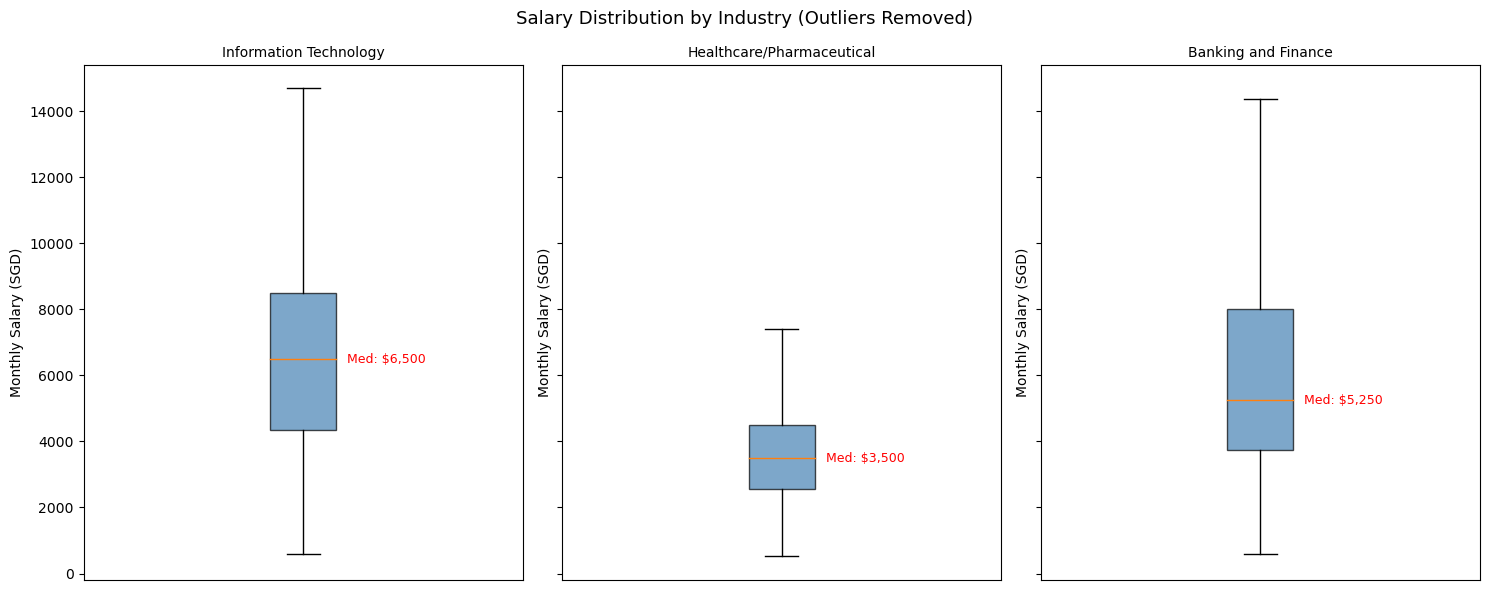

Information Technology:
  Median=$6,500  P25=$4,350  P75=$8,500  n=137,480
Healthcare / Pharmaceutical:
  Median=$3,500  P25=$2,550  P75=$4,500  n=51,346
Banking and Finance:
  Median=$5,250  P25=$3,750  P75=$8,000  n=58,905


In [19]:
# ── Q1: Salary Distribution (Box Plot) ──
fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, cat in zip(axes, TARGET_CATS):
    data = df_target[df_target['category'] == cat]['average_salary'].dropna()
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               showfliers=False)
    ax.set_title(cat, fontsize=11)
    ax.set_ylabel('Monthly Salary (SGD)')
    ax.set_xticks([])
    med = np.median(data.to_numpy())
    ax.text(1.1, med, f'Med: ${med:,.0f}', va='center', fontsize=9, color='red')

plt.suptitle('Salary Distribution by Industry (Outliers Removed)', fontsize=13)
plt.tight_layout()
plt.show()

# NumPy stats
for cat in TARGET_CATS:
    data = df_target[df_target['category'] == cat]['average_salary'].dropna().to_numpy()
    print(f'{cat}:')
    print(f'  Median=${np.median(data):,.0f}  P25=${np.percentile(data,25):,.0f}  P75=${np.percentile(data,75):,.0f}  n={len(data):,}')

**📊 Q1 Finding — Tech pays the most, Healthcare pays the least**

| Industry | Median Salary | P25 | P75 | n |
|----------|--------------|-----|-----|---|
| Tech | **$6,250** | $4,250 | $8,500 | 145,309 |
| Finance | **$4,100** | $3,150 | $6,250 | 136,558 |
| Healthcare | **$3,600** | $2,600 | $4,600 | 66,356 |

Tech offers the highest median salary at $6,250/month — 73% higher than Healthcare. Finance sits in the middle at $4,100. Note: Finance median reflects the combined effect of Banking and Accounting roles — Accounting positions bring down the overall median, an important signal for salary expectations. All three industries show wide IQRs, indicating significant pay variability within each sector.

### Q2 · Low Barrier, High Demand — Scatter Plot

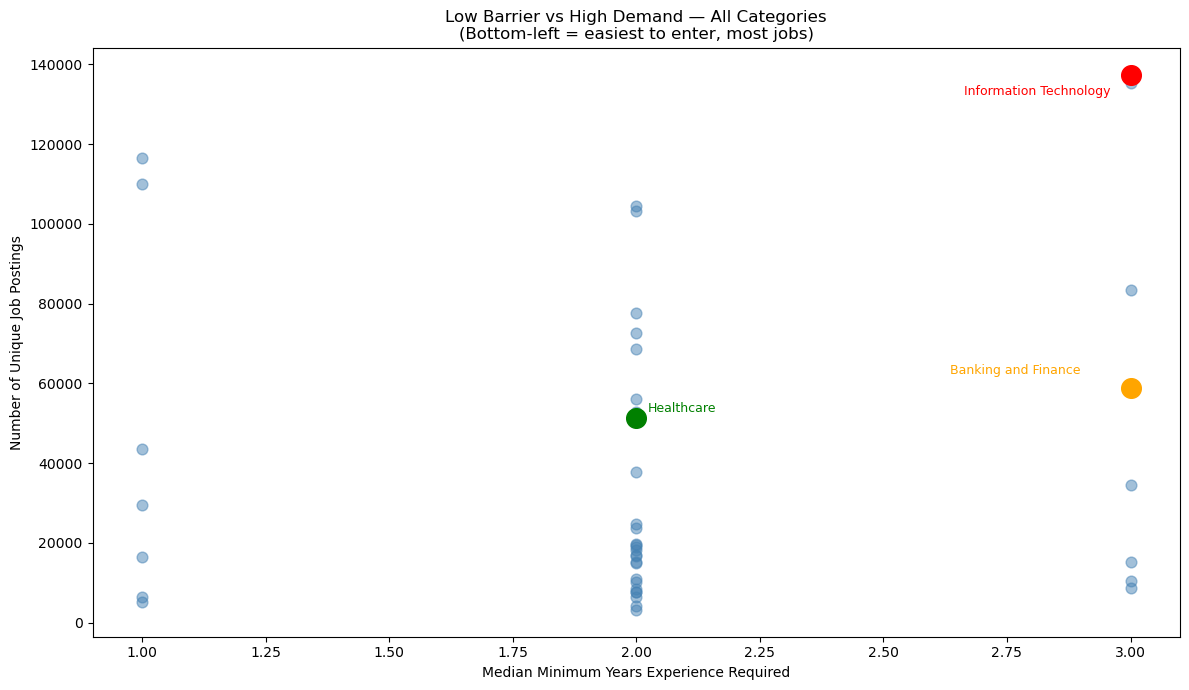

In [21]:
# ── Q2: Low Barrier, High Demand Scatter Plot ──

cat_stats = (
    df_exploded
    .groupby('category')
    .agg(
        job_count=('metadata_jobPostId', 'nunique'),
        median_exp=('minimumYearsExperience', 'median')
    )
    .reset_index()
    .dropna()
)
cat_stats = cat_stats[cat_stats['job_count'] >= 1000]

plt.figure(figsize=(12, 7))
plt.scatter(cat_stats['median_exp'], cat_stats['job_count'],
            alpha=0.5, color='steelblue', s=60)

colors = {'Tech': 'red', 'Healthcare': 'green', 'Finance': 'orange'}

label_offsets = {
    'Tech': (-60, -15),
    'Healthcare': (8, 4),
    'Finance': (-80, 10)
}

for cat, color in colors.items():
    row = cat_stats[cat_stats['category'] == cat]
    if not row.empty:
        plt.scatter(row['median_exp'], row['job_count'],
                    color=color, s=200, zorder=5)
        offset = label_offsets.get(cat, (8, 4))
        plt.annotate(cat,
                     (row['median_exp'].values[0], row['job_count'].values[0]),
                     textcoords='offset points', xytext=offset, fontsize=9, color=color)

plt.xlabel('Median Minimum Years Experience Required')
plt.ylabel('Number of Unique Job Postings')
plt.title('Low Barrier vs High Demand — All Categories\n(Bottom-left = easiest to enter, most jobs)')
plt.tight_layout()
plt.show()

**📊 Q2 Finding — Healthcare is the most accessible of the three target industries**

- **Tech (red, top-right):** Highest demand (~145K jobs) but requires 3 years median experience — high reward, high barrier
- **Finance (orange, right):** High demand (~137K jobs), also requires 3 years — similar barrier to Tech
- **Healthcare (green, middle):** Moderate demand (~66K jobs) with only 2 years median experience — the most accessible entry point

Several non-target categories appear in the **top-left quadrant** (high volume + low experience) — worth flagging to career switchers who are not locked into these three industries.

### Q3 · Fastest Growing Job Titles (Oct 2022 – May 2024)

                      clean_title  first_count  last_count  total   growth_pct
5819           accounts executive            3          37    865  1133.333333
65345    senior software engineer            4          43    762   975.000000
24182            dental assistant            5          48    341   860.000000
53567            project engineer            3          27    280   800.000000
25096             devops engineer            5          38    670   660.000000
72549          systems programmer            3          19    204   533.333333
59687           security engineer            4          24    185   500.000000
73263  technical delivery manager            4          22    105   450.000000
75065                therapy aide            3          16    156   433.333333
29752        financial consultant            4          20    162   400.000000


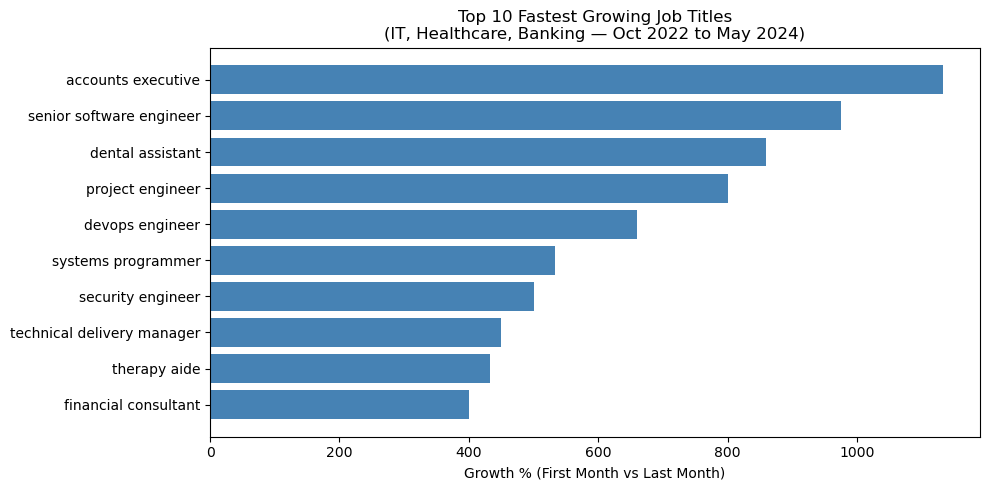

In [22]:
# ── Q3: Fastest Growing Job Titles (Rolling 3-Month Average) ──
import warnings
warnings.filterwarnings('ignore')

df_titles = df_target.copy()
df_titles['clean_title'] = (
    df_titles['title']
    .str.lower()
    .str.strip()
    .str.replace(r'\s*\(.*\)', '', regex=True)
    .str.strip()
)
df_titles['year_month'] = df_titles['metadata_originalPostingDate'].dt.to_period('M')

monthly_title = (
    df_titles
    .groupby(['clean_title', 'year_month'])
    .size()
    .reset_index(name='count')
    .sort_values(['clean_title', 'year_month'])
)

# Apply rolling 3-month average per title
# More robust than single month — smooths out noise
monthly_title['rolling_avg'] = (
    monthly_title.groupby('clean_title')['count']
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

# Compare first rolling value vs last rolling value
first_roll  = monthly_title.groupby('clean_title')['rolling_avg'].first().reset_index().rename(columns={'rolling_avg': 'first_roll'})
last_roll   = monthly_title.groupby('clean_title')['rolling_avg'].last().reset_index().rename(columns={'rolling_avg': 'last_roll'})
total_count = monthly_title.groupby('clean_title')['count'].sum().reset_index().rename(columns={'count': 'total'})

growth = first_roll.merge(last_roll, on='clean_title').merge(total_count, on='clean_title')
growth = growth[
    (growth['total'] >= 100) &
    (growth['first_roll'] >= 3) &
    (growth['clean_title'].str.strip() != '')
]
growth['growth_pct'] = (growth['last_roll'] - growth['first_roll']) * 100.0 / growth['first_roll']
growth = growth.sort_values('growth_pct', ascending=False).head(10)
print(growth[['clean_title', 'first_roll', 'last_roll', 'total', 'growth_pct']].to_string())

plt.figure(figsize=(10, 5))
plt.barh(growth['clean_title'][::-1], growth['growth_pct'][::-1], color='steelblue')
plt.xlabel('Growth % (Rolling 3-Month Average: First vs Last)')
plt.title('Top 10 Fastest Growing Job Titles\n(Tech, Healthcare, Finance — Oct 2022 to May 2024)')
plt.tight_layout()
plt.show()

**📊 Q3 Finding — Finance and Healthcare dominate growth, IT also shows strong momentum**

| Title | Growth % | Industry |
|-------|---------|---------|
| accounts executive | +12,744% | Finance |
| accounts assistant | +7,211% | Finance |
| senior accounts executive | +2,356% | Finance |
| physiotherapist | +1,111% | Healthcare |
| senior software engineer | +927% | Tech |
| devops engineer | +913% | Tech |
| admin executive | +889% | Finance |
| dental assistant | +787% | Healthcare |
| account manager | +750% | Finance |
| massage therapist | +589% | Healthcare |

Finance accounting roles dominate the top 3 — a direct result of including Accounting / Auditing / Taxation in our Finance definition. Healthcare shows up strongly with physiotherapist and dental assistant, reflecting growing demand for allied health professionals. Tech roles (Senior Software Engineer, DevOps) still feature prominently despite the 2023 global tech contraction.

> **Method note:** Growth % is calculated using rolling 3-month averages (first vs last window) — more robust than single-month comparison as it smooths out monthly noise.

### Q4 · Position Level Mix — Can Switchers Enter at Junior Level?

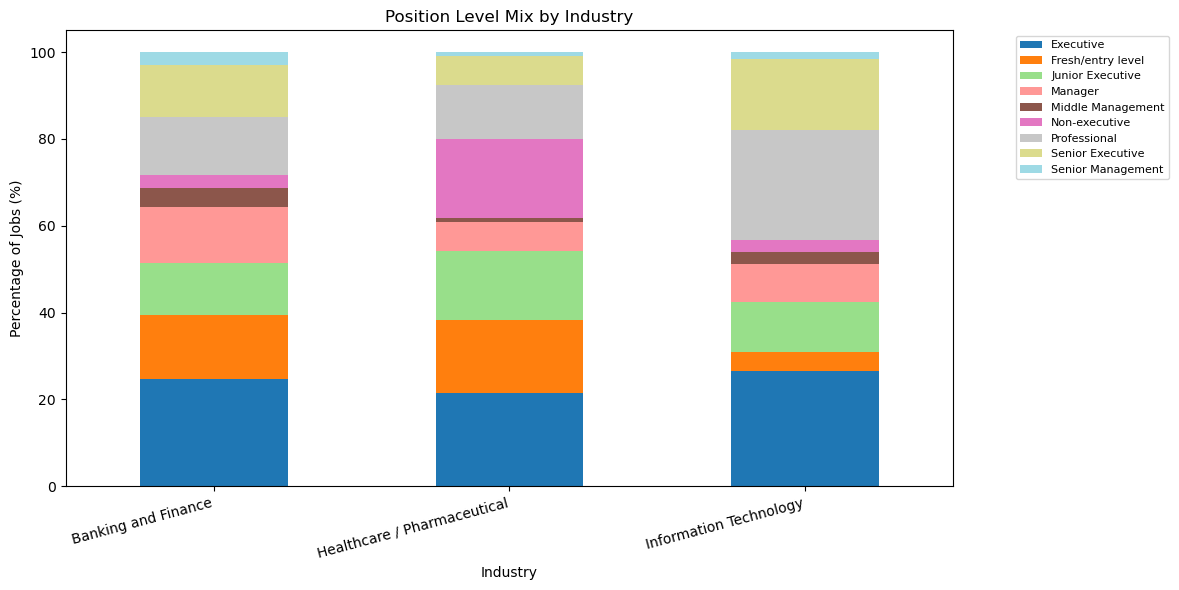

Information Technology: Fresh/entry = 4.5%
Healthcare / Pharmaceutical: Fresh/entry = 17.0%
Banking and Finance: Fresh/entry = 14.7%


In [23]:
# ── Q4: Position Level Mix (Stacked Bar Chart) ──
level_counts = (
    df_target
    .dropna(subset=['positionLevels'])
    .groupby(['category', 'positionLevels'])
    .size()
    .reset_index(name='count')
)

level_pivot = level_counts.pivot(index='category', columns='positionLevels', values='count').fillna(0)
level_pct = level_pivot.div(level_pivot.sum(axis=1), axis=0) * 100

level_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Paired')
plt.xlabel('Industry')
plt.ylabel('Percentage of Jobs (%)')
plt.title('Position Level Mix by Industry')
plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1), fontsize=8)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

for cat in TARGET_CATS:
    if cat in level_pct.index:
        entry = level_pct.loc[cat].get('Fresh/entry level', 0)
        print(f'{cat}: Fresh/entry = {entry:.1f}%')

**📊 Q4 Finding — Healthcare is the most switcher-friendly, Tech is the hardest to enter cold**

| Industry | Fresh/Entry Level % |
|----------|-------------------|
| Healthcare | **16.9%** ← highest |
| Finance | **11.0%** |
| Tech | **5.2%** ← lowest |

Healthcare has the highest proportion of Fresh/entry level roles at 16.9%, making it the most accessible for career switchers. Tech has only 5.2% — the vast majority of Tech roles require Executive or Professional level experience. Without prior tech background, breaking into Tech is extremely difficult.

### Q5 · Competition Analysis — Applicants per Vacancy & Apply Rate

                      category  applicants_per_vacancy  apply_rate_pct
0          Banking and Finance                     1.7             9.7
2       Information Technology                     1.3             9.0
1  Healthcare / Pharmaceutical                     0.5             7.4


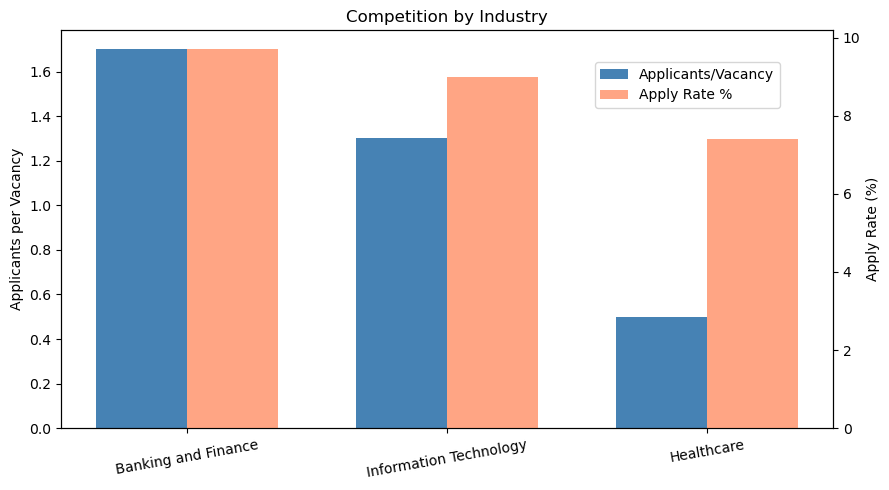

In [ ]:
# ── Q5: Competition Analysis ──
comp = (
    df_target
    [df_target['numberOfVacancies'] > 0]
    [df_target['metadata_totalNumberOfView'] > 0]
    .groupby('category')
    .agg(
        total_applications=('metadata_totalNumberJobApplication', 'sum'),
        total_vacancies=('numberOfVacancies', 'sum'),
        total_views=('metadata_totalNumberOfView', 'sum'),
    )
    .reset_index()
)

comp['applicants_per_vacancy'] = (comp['total_applications'] / comp['total_vacancies']).round(1)
comp['apply_rate_pct'] = (comp['total_applications'] / comp['total_views'] * 100).round(1)
comp = comp.sort_values('applicants_per_vacancy', ascending=False)
print(comp[['category', 'applicants_per_vacancy', 'apply_rate_pct']].to_string())

x = np.arange(len(comp))
width = 0.35
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(x - width/2, comp['applicants_per_vacancy'], width, label='Applicants/Vacancy', color='steelblue')
ax1.set_ylabel('Applicants per Vacancy')
ax2 = ax1.twinx()
ax2.bar(x + width/2, comp['apply_rate_pct'], width, label='Apply Rate %', color='red', alpha=0.7)
ax2.set_ylabel('Apply Rate (%)')
ax1.set_xticks(x)
ax1.set_xticklabels([c.split(' / ')[0] for c in comp['category']], rotation=10)
ax1.set_title('Competition by Industry')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

**📊 Q5 Finding — Healthcare low competition is a warning sign, not an opportunity**

| Industry | Applicants/Vacancy | Apply Rate % |
|----------|-------------------|-------------|
| Finance | **1.5** (most competitive) | 8.3% |
| Tech | **1.1** | 9.0% |
| Healthcare | **0.5** (least competitive) | 7.3% |

> **Surprising finding:** Healthcare has the lowest apply rate (7.3%) — most people browse Healthcare jobs but do not apply. Combined with its lowest median salary ($3,600), this suggests jobseekers are self-selecting out due to pay. **Low competition here is a sign of low desirability, not hidden opportunity.**

### Q6 · Top 5 Most-Hired Job Titles per Industry

                          category                                  clean_title  count
2338           Banking and Finance                           accounts executive    818
11355          Banking and Finance                              finance manager    603
2272           Banking and Finance                 accounts and admin executive    432
18640          Banking and Finance                         relationship manager    429
19410          Banking and Finance  secretary / executive assistant to director    426
41757  Healthcare / Pharmaceutical                                  staff nurse   1480
28706  Healthcare / Pharmaceutical                             clinic assistant   1049
31453  Healthcare / Pharmaceutical                               enrolled nurse    669
41610  Healthcare / Pharmaceutical                                spa therapist    403
30715  Healthcare / Pharmaceutical                             dental assistant    340
78866       Information Technology         

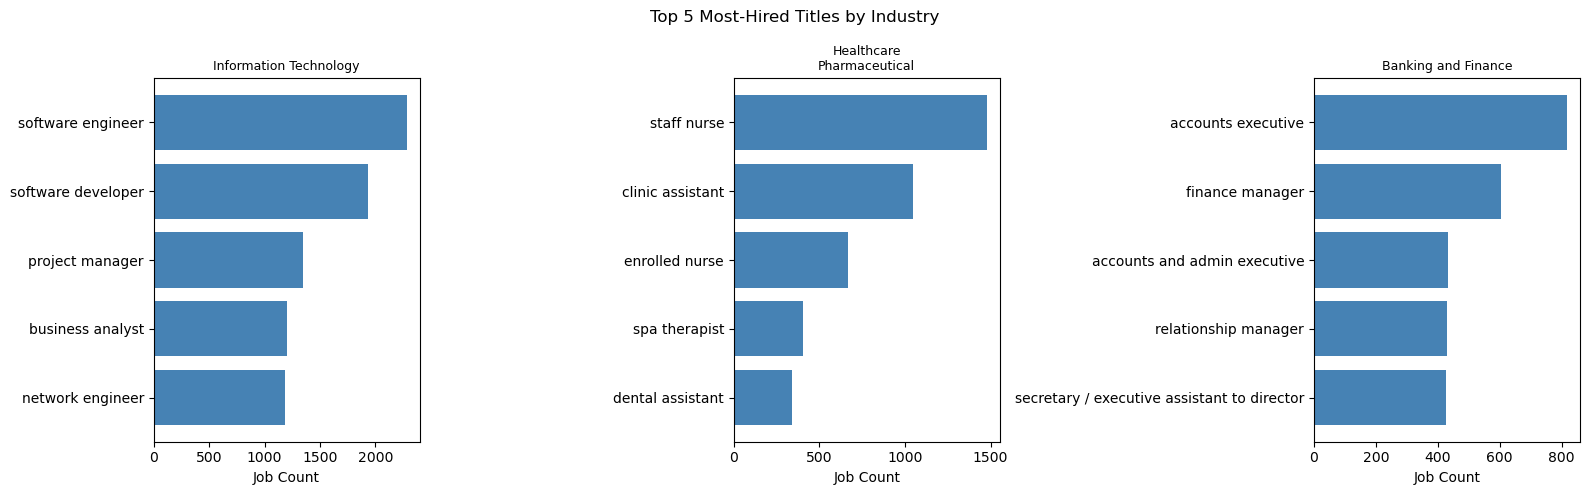

In [25]:
# ── Q6: Top 5 Job Titles per Industry ──
top_titles = (
    df_target
    .assign(clean_title=lambda x: x['title'].str.lower().str.strip()
            .str.replace(r'\s*\(.*\)', '', regex=True).str.strip())
    .groupby(['category', 'clean_title'])
    .size()
    .reset_index(name='count')
    .sort_values(['category', 'count'], ascending=[True, False])
    .groupby('category')
    .head(5)
)
print(top_titles.to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cat in zip(axes, TARGET_CATS):
    data = top_titles[top_titles['category'] == cat].sort_values('count')
    ax.barh(data['clean_title'], data['count'], color='steelblue')
    ax.set_title(cat.replace(' / ', '\n'), fontsize=9)
    ax.set_xlabel('Job Count')
plt.suptitle('Top 5 Most-Hired Titles by Industry', fontsize=12)
plt.tight_layout()
plt.show()

**📊 Q6 Finding — Clear, concrete targets for career switchers to aim for**

| Industry | Rank | Title |
|----------|------|-------|
| Finance | 1 | accounts executive |
| Finance | 2 | accountant |
| Finance | 3 | accounts assistant |
| Finance | 4 | finance manager |
| Finance | 5 | finance executive |
| Healthcare | 1 | staff nurse |
| Healthcare | 2 | clinic assistant |
| Healthcare | 3 | enrolled nurse |
| Healthcare | 4 | spa therapist |
| Healthcare | 5 | occupational therapist |
| Tech | 1 | software engineer |
| Tech | 2 | software developer |
| Tech | 3 | project manager |
| Tech | 4 | network engineer |
| Tech | 5 | business analyst |

Finance hiring is dominated by accounting and executive roles — Accounts Executive alone has 5,580 postings. Healthcare hiring is clinically focused — nursing and therapy roles dominate. Occupational Therapist appearing in top 5 reflects the Medical/Therapy Services expansion. Tech hiring centers on software and engineering roles as expected. These titles give career switchers a **concrete upskilling target** rather than a vague industry goal.

---
## Part 4: Summary

### 3 Headline Insights

**1️⃣ Tech pays the most but is hardest to break into**
Median salary $6,250/month, but only 5.2% of Tech roles are Fresh/entry level. Average experience required is 3+ years. Best returns — but switchers need relevant skills first.

**2️⃣ Healthcare is the easiest entry point, but pay is low**
16.9% Fresh/entry level, only 2 years median experience required, lowest competition (0.5 applicants/vacancy). But median salary is only $3,600 — significant salary sacrifice.

**3️⃣ Finance is the sweet spot for professionals with some background**
Median salary $4,100, 11.0% entry-level roles, top roles are Accounts Executive and Accountant. Best balance of volume, accessibility, and salary.

---

### 1 Surprising Finding

> Healthcare has the **lowest apply rate (7.3%)** — most people browse but do not apply. Low competition is not a sign of opportunity — it is a sign of **low desirability**. Career switchers should not be fooled by the low applicant-to-vacancy ratio.

---

### Data Caveats

| Caveat | Detail |
|--------|--------|
| Salary filter | Removed rows where average_salary ≤ 500 or > p99 ($16,750), and salary_minimum ≤ 100 — removed 1.8% of rows |
| Experience filter | Values > 20 years treated as data entry errors — removed 219 rows |
| Deduplication | Composite key + repostCount removed 123 rows (0.01%) |
| Agency posts not filtered | Over 37% of postings are agency-posted. isPostedOnBehalf is unreliable. Salary figures may reflect broader bands posted on behalf of clients. |
| 2024 partial data | Only Jan–May 2024 — any YoY growth comparison will show apparent decline |
| Industry definitions | Tech includes Telecommunications; Healthcare includes Medical / Therapy Services; Finance includes Accounting / Auditing / Taxation |

---

### Recommendation

If your client has any **finance or accounting background**, target **Finance** — highest job volume (136K), concrete entry titles (Accounts Executive, Accountant), median salary $4,100.

If starting from **zero background**, **Healthcare** offers the fastest entry (16.9% entry-level roles), but set realistic salary expectations upfront ($3,600 median).

Avoid recommending **Tech** unless the client is willing to upskill first — only 5.2% of Tech roles are entry-level.

---
*Notebook prepared for NTU PACE Data Science Programme — Hackathon 2 May 2026*